[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/carlospi2000/Notes_on_Computational_Physics/blob/main/04.Random_Numbers_generation_PYTHON/04_NumerosAleatorios_Difusion_Python_revisado.ipynb)

## Números pseudoaleatorios y difusión en Python
**Física Computacional — 106018C** · CRISTIAN ANDRÉS CÁRDENAS MUÑOZ


Esta semana estudiaremos la generación de números pseudoaleatorios y su uso en modelos estocásticos de procesos físicos. Una descripción estocástica también puede representar sistemas con dinámica microscópica determinista cuyo movimiento detallado no conocemos. Aplicaremos estas ideas a una caminata aleatoria unidimensional para estudiar la dispersión de partículas.

## Objetivos
- Distinguir una distribución uniforme de una secuencia independiente.
- Usar una semilla para repetir y depurar una simulación.
- Traducir números uniformes en $[0,1)$ a pasos aleatorios.
- Programar ciclos y acumuladores para varias caminatas.
- Calcular $\langle x_n\rangle$ y $\langle x_n^2\rangle$ como observables.
- Usar lo aprendido en la semana anterior sobre ajuste lineal, ahora en Python, para estimar el coeficiente de difusión $D$.
- Comprobar cómo un generador deficiente distorsiona un resultado físico.
- Expresar el coeficiente de difusión en unidades reales y extraer consecuencias físicas.

**Flujo:** ejecute las celdas de arriba hacia abajo. Las celdas marcadas `TODO` requieren su trabajo antes de ejecutar el taller completo. No se necesitan archivos de datos externos.

## 1. ¿Qué significa pseudoaleatorio?

Una computadora reproduce una secuencia de numeros si repetimos su algoritmo y su semilla. En python `random.Random(semilla)` crea un generador local: sus llamadas no interfieren con las de otras celdas. Para simulación físicas reales usaremos el generador de la biblioteca estándar, no el pequeño generador congruencial de ejemplo siguiente.

In [ ]:
# --- Bibliotecas ---
import random                    # generador pseudoaleatorio de la biblioteca estándar
import numpy as np               # arreglos numéricos (arreglos, lectura y visualización)
import matplotlib.pyplot as plt  # gráficas

# --- Dos objetos generadores con la MISMA semilla ---
rng1 = random.Random(42)
rng2 = random.Random(42)

# --- Cinco números de cada uno ---
secuencia1 = [rng1.random() for _ in range(5)]
secuencia2 = [rng2.random() for _ in range(5)]

# --- Comprobación: misma semilla => misma secuencia (reproducibilidad) ---
print("Primera secuencia:", secuencia1)
print("Segunda secuencia:", secuencia2)
print("Misma semilla, misma secuencia:", secuencia1 == secuencia2)


Primera secuencia: [0.6394267984578837, 0.025010755222666936, 0.27502931836911926, 0.22321073814882275, 0.7364712141640124]
Segunda secuencia: [0.6394267984578837, 0.025010755222666936, 0.27502931836911926, 0.22321073814882275, 0.7364712141640124]
Misma semilla, misma secuencia: True


### Generador lineal congruente

Las diapositivas presentan que una forma popular para la generacion de numeros aleatorios es la ecuacion
$$
r_{i+1}=(a r_i+c)\bmod (M)
$$
Aquí $M$ es un entero positivo que determina el rango de estados, de 0 a $M-1$. Algunos generadores usan módulos como $2^{32}$ o $2^{48}$; el módulo no es el número de bits. El multiplicador $a$ y el incremento $c$ se seleccionan cuidadosamente. En este caso con $a=4$, $c=1$, $M=9$ y semilla $r_1=3$, la secuencia termina repitiéndose despues de algunas iteraciones. El valor escalado $u_i=r_i/M$ pertenece a $[0,1)$, pero esta transformación **no aumenta** el período. Observe por qué cada valor vuelve a aparecer después de nueve pasos. Este generador pequeño **solo** sirve para estudiar el algoritmo; el taller usa `random.Random`.

<div style="background-color:#fdecea; border-left:5px solid #e53935; padding:10px 15px; margin:10px 0;"><b>Cuidado:</b> una secuencia puede repartir sus valores sobre el intervalo y aun así mostrar patrones entre valores consecutivos. Uniformidad e independencia responden preguntas distintas.</div>

In [ ]:
# --- Parámetros del generador congruente de las diapositivas ---
a_lcg, c_lcg, M, r = 4, 1, 9, 3   # multiplicador, incremento, módulo y semilla r_1

# --- Generar 12 enteros para ver cuándo se repite la secuencia ---
enteros = []
for _ in range(12):
    enteros.append(r)              # Guarda el estado actual antes de actualizarlo.
    r = (a_lcg*r + c_lcg) % M      # El módulo lo devuelve al rango 0,...,M-1.

# --- Resultados: enteros y su versión escalada a [0, 1) ---
print("Enteros:", enteros)
print("Escalados a [0, 1):", [valor/M for valor in enteros])  # división real, no entera


Enteros: [3, 4, 8, 6, 7, 2, 0, 1, 5, 3, 4, 8]
Escalados a [0, 1): [0.3333333333333333, 0.4444444444444444, 0.8888888888888888, 0.6666666666666666, 0.7777777777777778, 0.2222222222222222, 0.0, 0.1111111111111111, 0.5555555555555556, 0.3333333333333333, 0.4444444444444444, 0.8888888888888888]


### Ejercicio 1a — Período y cambio de intervalo

En las diapositivas se proponen dos ejercicios en clase con generadores congruenciales:

1. **Período.** Programe el generador $(a,c,M,r_1)=(57,1,256,10)$ con un ciclo `while` y cuente cuántos números produce antes de que reaparezca el primer valor generado. Compare con el máximo posible, $M=256$.
2. **Cambio de intervalo.** Escale la secuencia del ejemplo $(4,1,9,3)$ al intervalo $[10,20)$ con $y_i = A + (B-A)\,x_i$. Los primeros valores deben ser 13.33, 14.44 y 18.89.

Un período máximo no garantiza calidad: en la Parte D se verá el efecto de este generador sobre un resultado físico.

Use el codigo dado aqui abajo para completar las partes y resolver este ejercicio


In [ ]:
# Ejercicio 1a — Período y cambio de intervalo

# --- 1. Período del LCG (57, 1, 256) con semilla 10 ---
a_lcg, c_lcg, M = 57, 1, 256
r = (a_lcg*10 + c_lcg) % M
primero = r
periodo = 1
r = (a_lcg*r + c_lcg) % M

while r != primero:
    r = (a_lcg*r + c_lcg) % M
    periodo += 1

print("Período:", periodo, "de", M, "posibles")

# --- 2. Cambio de intervalo: secuencia (4, 1, 9, 3) llevada a [10, 20) ---
A, B = 10.0, 20.0
r = 3
for _ in range(5):
    x = r/9
    y = A + (B - A)*x
    print(f"r = {r}   x = {x:.3f}   y = {y:.2f}")
    r = (4*r + 1) % 9


Período: 256 de 256 posibles
r = 3   x = 0.333   y = 13.33
r = 4   x = 0.444   y = 14.44
r = 8   x = 0.889   y = 18.89
r = 6   x = 0.667   y = 16.67
r = 7   x = 0.778   y = 17.78


### Ejercicio 1b — Inspección sencilla

Complete el ciclo. Para una distribución uniforme en $[0,1)$, la media debe acercarse a $1/2$ y el promedio de productos de vecinos independientes a $1/4$. Son diagnósticos aproximados, no certificados de calidad del generador. Compare también un gráfico de pares consecutivos $(u_i,u_{i+1})$.

Media: 0.4950164221295824 (esperada ≈ 0.5)
Producto de vecinos: 0.2446517326460888 (esperado ≈ 0.25)


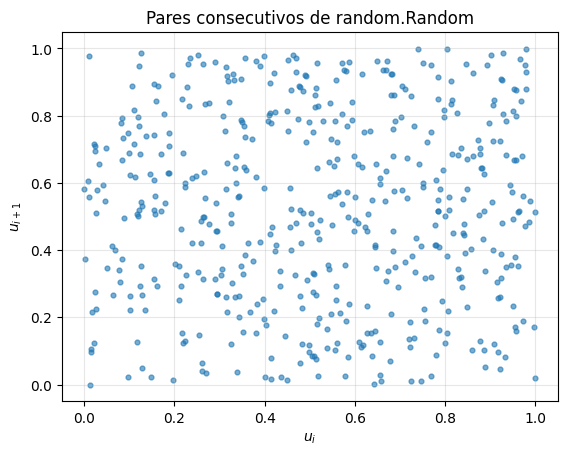

In [ ]:
# Ejercicio 1b — Inspección sencilla

# --- Preparación: generador con semilla fija y acumuladores en cero ---
rng = random.Random(2026)
N_muestra = 10_000
suma = 0.0
suma_vecinos = 0.0
anterior = rng.random()
pares = []

# --- Ciclo principal ---
for _ in range(N_muestra):
    actual = rng.random()
    suma += actual
    suma_vecinos += anterior * actual
    if len(pares) < 500:
        pares.append((anterior, actual))
    anterior = actual

print("Media:", suma/N_muestra, "(esperada ≈ 0.5)")
print("Producto de vecinos:", suma_vecinos/N_muestra, "(esperado ≈ 0.25)")

# --- Gráfica de pares consecutivos ---
x_pares = [p[0] for p in pares]
y_pares = [p[1] for p in pares]
plt.scatter(x_pares, y_pares, s=12, alpha=0.6)
plt.xlabel(r"$u_i$")
plt.ylabel(r"$u_{i+1}$")
plt.title("Pares consecutivos de random.Random")
plt.grid(alpha=0.3)
plt.show()


## 2. Movimiento aleatorio de una partícula en una dimension

Estudiemos ahora el caso de una particula que se mueve de forma unidimensional bajo la siguiente condición: si $u<0.5$, damos un paso a la derecha $+a$; si $u\geq0.5$, uno a la izquierda $-a$. En el modelo, cada paso es independiente y dura el mismo intervalo $\Delta t$. La posición comienza en $x_0=0$ y evoluciona como $x_n=\sum_{i=1}^{n}s_i$.

| Número generado | Paso | Posición nueva |
|---|---:|---:|
| $u=0.2$ | $+a$ | $x_{n+1}=x_n+a$ |
| $u=0.8$ | $-a$ | $x_{n+1}=x_n-a$ |

Con $a=1$ y $x_0=0$, los valores $0.2,0.8,0.2$ producen las posiciones $0,1,0,1$. Esta secuencia corta servirá también para comprobar funciones del taller.

Posiciones: [0.0, 1.0, 2.0, 1.0, 2.0, 1.0, 2.0, 3.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 6.0, 7.0, 8.0, 7.0, 6.0, 5.0, 6.0]


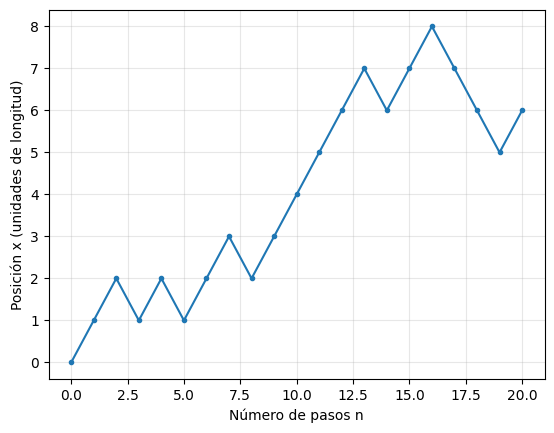

In [ ]:
# Ejemplo completo: una caminata de 20 pasos.

# --- Parámetros y condición inicial ---
rng = random.Random(7)     # semilla fija: la caminata se puede repetir
longitud_paso = 1.0        # a
x = 0.0                    # x_0 = 0
posiciones = [x]           # contiene también la posición inicial

# --- Ciclo de pasos: número uniforme -> paso +a o -a ---
for _ in range(20):
    u = rng.random()
    paso = longitud_paso if u < 0.5 else -longitud_paso   # derecha si u<0.5
    x += paso                                           # x_{n+1} = x_n + s_n
    posiciones.append(x)

# --- Resultado numérico y gráfica de la trayectoria ---
print("Posiciones:", posiciones)
plt.plot(range(len(posiciones)), posiciones, marker="o", markersize=3)
plt.xlabel("Número de pasos n")
plt.ylabel("Posición x (unidades de longitud)")
plt.grid(alpha=0.3)
plt.show()


### Ejercicio 2. Segunda Caminata

Repita el ejemplo con otra semilla. Compare las posiciones finales y las formas de las dos trayectorias. ¿Alguna trayectoria aislada muestra una línea recta cuando se representa $x_n^2$ frente a $n$? Explique por qué necesitamos promediar.

Posición final de la primera caminata: 6.0
Posición final de la segunda caminata: 6.0


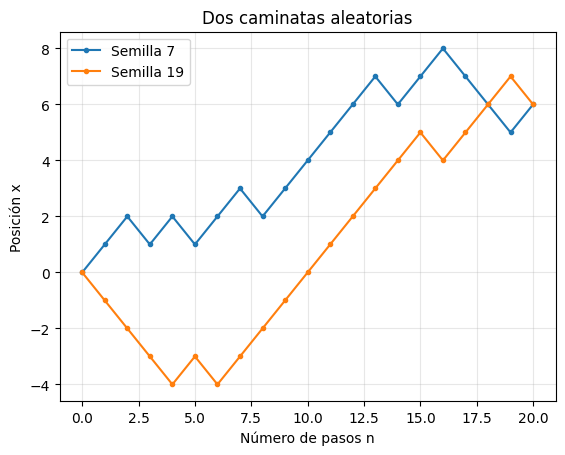

In [ ]:
# Ejercicio 2 — Segunda caminata

# --- Segunda caminata con otra semilla ---
rng = random.Random(19)  # diferente de 7
x = 0.0
segunda = [x]

for _ in range(20):
    u = rng.random()
    x += 1.0 if u < 0.5 else -1.0
    segunda.append(x)

print("Posición final de la primera caminata:", posiciones[-1])
print("Posición final de la segunda caminata:", segunda[-1])

# --- Comparación gráfica ---
plt.plot(range(len(posiciones)), posiciones, marker="o", markersize=3, label="Semilla 7")
plt.plot(range(len(segunda)), segunda, marker="o", markersize=3, label="Semilla 19")
plt.xlabel("Número de pasos n")
plt.ylabel("Posición x")
plt.title("Dos caminatas aleatorias")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# En una trayectoria aislada x_n^2 también fluctúa; la relación lineal
# aparece estadísticamente al promediar muchas caminatas independientes.


## 3. Por qué aparece la difusión

Para $s_i=\pm a$ con igual probabilidad e independencia, $\langle s_i\rangle=0$ y $\langle s_i^2\rangle=a^2$. Por tanto,

$$\langle x_n\rangle=0,\qquad
\langle x_n^2\rangle=\sum_i\langle s_i^2\rangle+
2\sum_{i<j}\langle s_i s_j\rangle=na^2.$$

Los términos cruzados desaparecen **al promediar muchas caminatas independientes**. No desaparecen necesariamente en una caminata concreta. Como $t=n\Delta t$ y la ley de difusión en una dimensión es $\langle x^2\rangle=2Dt$, donde $D$ es el **coeficiente de difusión** (mide qué tan rápido se dispersan las partículas),

$$D=\frac{a^2}{2\Delta t}, \qquad
x_{\rm rms}(n)=\sqrt{\langle x_n^2\rangle}=a\sqrt n.$$

Las unidades del coeficiente de difusión son longitud$^2$/tiempo (m$^2$/s en el SI). Las diapositivas mencionan también la generalización a $d$ dimensiones, $\langle r^2\rangle=2dDt$: una caminata **bidimensional con pasos continuos** en $[-1,1)$ da $\langle R^2\rangle=2n/3$. No se debe usar esa pendiente para esta caminata de pasos $\pm a$.

### Ejemplo completo: acumular muchas caminatas

El arreglo `suma_x2[n]` suma $x_n^2$ de todas las partículas. Reiniciamos `x` para cada partícula, pero **no** los acumuladores. Guardamos el punto inicial $n=0$.

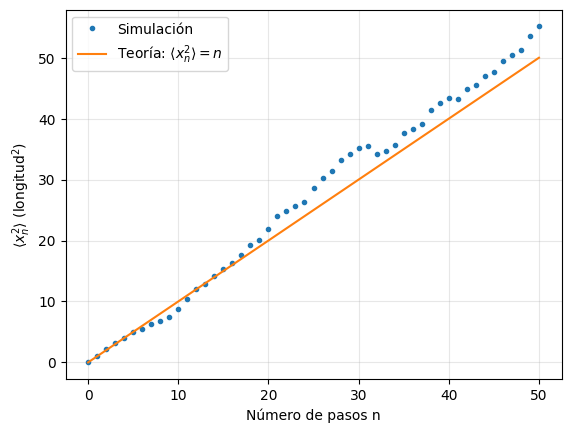

Media de x al final: 0.57


In [ ]:
# Ejemplo completo: K caminantes independientes, N pasos por caminante.

# --- Parámetros y acumuladores (uno por cada instante n) ---
K_demo, N_demo = 200, 50
rng = random.Random(11)  # Una semilla para el experimento completo.
suma_x = [0.0]*(N_demo + 1)   # La posición inicial ocupa el índice 0.
suma_x2 = [0.0]*(N_demo + 1)  # Misma estructura para x_n al cuadrado.

# --- Ciclo externo: caminantes; ciclo interno: pasos ---
for caminante in range(K_demo):
    x = 0.0  # Cada caminante parte del origen; las sumas NO se reinician.
    for n in range(1, N_demo + 1):
        x += 1.0 if rng.random() < 0.5 else -1.0
        suma_x[n] += x       # Acumula x_n de este caminante.
        suma_x2[n] += x*x    # Acumula x_n² en el mismo instante n.

# --- Promedios: se divide por K una sola vez, al final ---
n_demo = np.arange(N_demo + 1)
media_x = np.array(suma_x)/K_demo   # <x_n>
msd = np.array(suma_x2)/K_demo      # <x_n^2>, desplazamiento cuadrático medio

# --- Comparación con la teoría <x_n^2> = n a^2 (a = 1) ---
plt.plot(n_demo, msd, "o", markersize=3, label="Simulación")
plt.plot(n_demo, n_demo, label=r"Teoría: $\langle x_n^2\rangle=n$")
plt.xlabel("Número de pasos n")
plt.ylabel(r"$\langle x_n^2\rangle$ (longitud$^2$)")
plt.legend(); plt.grid(alpha=0.3); plt.show()
print("Media de x al final:", media_x[-1])


### ¿Qué representa cada promedio?

`media_x[n]` aproxima $\langle x_n\rangle$: en una caminata simétrica esperamos cero. `msd[n]` aproxima $\langle x_n^2\rangle$: es positivo y aumenta aproximadamente como $n$. **No son lo mismo** $\langle x_n^2\rangle$ y $\langle x_n\rangle^2$; elevar al cuadrado la media borraría la dispersión que queremos medir.

Si aumentamos $K$, el promedio estimado suele acercarse a la predicción. Eso no hace menos errática cada trayectoria individual. Un buen resultado estadístico tampoco demuestra que una secuencia sea verdaderamente aleatoria.

### Ejercicio 3 — Comparar el tamaño del conjunto

Modifique **solo** `K_demo` en el ejemplo anterior: compare $K=20$ y $K=2000$, manteniendo `N_demo` y la semilla. Anote cómo cambia la gráfica de $\langle x_n^2\rangle$. No espere que todos los puntos queden exactamente sobre la línea teórica: el promedio se calcula con una muestra finita.

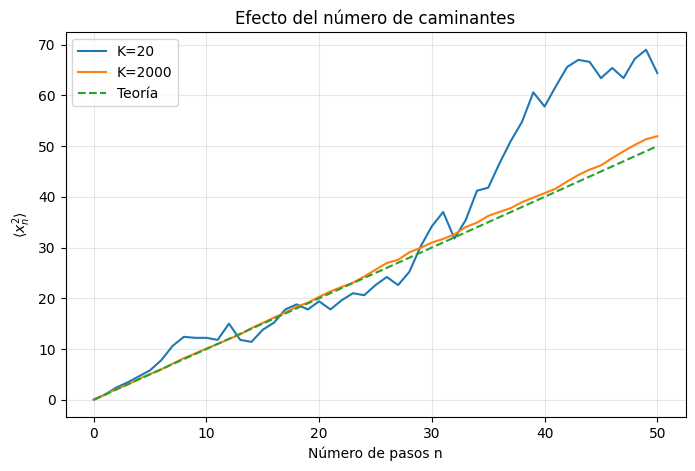

In [ ]:
# Ejercicio 3 — Comparar K=20 y K=2000 manteniendo N y semilla
N_comparacion = 50
semilla_comparacion = 11

plt.figure(figsize=(8, 5))
for K_comparacion in (20, 2000):
    rng_comp = random.Random(semilla_comparacion)
    suma_x2_comp = [0.0]*(N_comparacion + 1)

    for _ in range(K_comparacion):
        x = 0.0
        for n in range(1, N_comparacion + 1):
            x += 1.0 if rng_comp.random() < 0.5 else -1.0
            suma_x2_comp[n] += x*x

    msd_comp = [valor/K_comparacion for valor in suma_x2_comp]
    plt.plot(range(N_comparacion + 1), msd_comp, label=f"K={K_comparacion}")

plt.plot(range(N_comparacion + 1), range(N_comparacion + 1), "--", label="Teoría")
plt.xlabel("Número de pasos n")
plt.ylabel(r"$\langle x_n^2\rangle$")
plt.title("Efecto del número de caminantes")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**Observación.** Con $K=20$ el promedio presenta fluctuaciones visibles alrededor de la recta teórica. Con $K=2000$ la curva es, en general, más estable porque el promedio usa una muestra mucho mayor. Esto no vuelve menos irregular a cada caminata individual; reduce la fluctuación estadística del promedio.

## 4. Ajustando mínimos cuadrados en Python

Ajustaremos $y_n=mn+b$, con $y_n=\langle x_n^2\rangle$. Para $q$ puntos $(n_i,y_i)$:

$$m=\frac{q\sum n_i y_i-(\sum n_i)(\sum y_i)}{q\sum n_i^2-(\sum n_i)^2},\qquad
b=\frac{\sum y_i-m\sum n_i}{q}.$$

Aunque la relación teórica pasa por $(0,0)$, dejamos libre $b$ para examinar fluctuaciones y errores de implementación. La estimación es $D_{\rm est}=m/(2\Delta t)$. El punto $n=0$ se incluye en el ajuste.

In [ ]:
# Ejemplo con datos exactos: comprobar la fórmula sin usar np.polyfit.

# --- Datos que cumplen exactamente y = 3x + 2 ---
x_ej = [0.0, 1.0, 2.0, 3.0]
y_ej = [2.0, 5.0, 8.0, 11.0]

# --- Sumas de mínimos cuadrados (las mismas de la semana 3) ---
q = len(x_ej)                               # número de puntos
sx, sy = sum(x_ej), sum(y_ej)               # suma de x y suma de y
sxx = sum(valor*valor for valor in x_ej)    # suma de x^2
sxy = sum(u*v for u, v in zip(x_ej, y_ej))  # suma de x*y

# --- Pendiente e intercepto ---
denominador = q*sxx - sx*sx
m_ej = (q*sxy - sx*sy)/denominador
b_ej = (sy - m_ej*sx)/q
print(f"m={m_ej}, b={b_ej}")  # 3.0 y 2.0


m=3.0, b=2.0


# Taller 4: Medir la difusión con caminatas aleatorias



## Parte A — Funciones de la simulación

Complete las tres funciones de la siguiente celda:

1. `generar_paso(rng,a)`: consuma **un** número del generador recibido y devuelva $+a$ o $-a$.
2. `caminar(N,a,rng)`: valide $N\geq0$ y $a>0$; devuelva **$N+1$ posiciones**, incluida $x_0=0$.
3. `simular_caminatas(K,N,a,semilla,generador=None)`: valide $K>0$, $N\geq0$ y $a>0$. Si `generador` es `None`, cree **un solo** `random.Random(semilla)` al inicio; si se entrega un generador, úselo en su lugar (lo necesitará en la Parte D). Pase ese mismo generador a cada caminata y acumule $x_n$ y $x_n^2$ para todos los $n$.
4. Divida cada suma por $K$ **después** del ciclo sobre caminantes. Devuelva `(media_x, media_x2)`.

Use `ValueError` para parámetros inválidos. No reinicie la semilla dentro del ciclo de caminantes: eso repetiría la misma trayectoria $K$ veces.

<div style="background-color:#eef7ee; border-left:5px solid #4caf50; padding:10px 15px; margin:10px 0;"><b>Prueba manual:</b> para <code>N=0</code>, la trayectoria y ambos promedios deben contener solamente el cero inicial.</div>

In [ ]:
def generar_paso(rng, a):
    """Un paso de longitud a: derecha si u<0.5, izquierda si u>=0.5."""
    u = rng.random()
    return a if u < 0.5 else -a


def caminar(N, a, rng):
    """Construye [x_0, x_1, ..., x_N] a partir del generador recibido."""
    if N < 0:
        raise ValueError("N debe ser mayor o igual que 0")
    if a <= 0:
        raise ValueError("a debe ser positivo")

    x = 0.0
    posiciones = [x]
    for _ in range(N):
        x += generar_paso(rng, a)
        posiciones.append(x)
    return posiciones


def simular_caminatas(K, N, a, semilla, generador=None):
    """Promedia x_n y x_n² en K caminatas; incluye el índice n=0."""
    if K <= 0:
        raise ValueError("K debe ser positivo")
    if N < 0:
        raise ValueError("N debe ser mayor o igual que 0")
    if a <= 0:
        raise ValueError("a debe ser positivo")

    # Se crea un solo generador para todo el experimento.
    rng = random.Random(semilla) if generador is None else generador
    suma_x = [0.0]*(N + 1)
    suma_x2 = [0.0]*(N + 1)

    for _ in range(K):
        trayectoria = caminar(N, a, rng)
        for n in range(N + 1):
            suma_x[n] += trayectoria[n]
            suma_x2[n] += trayectoria[n]**2

    media_x = [valor/K for valor in suma_x]
    media_x2 = [valor/K for valor in suma_x2]
    return media_x, media_x2


## Parte B — Ajuste y coeficiente de difusión

Complete el ajuste con las sumas de la sección 4. La función debe devolver `(pendiente, intercepto)` y usar `ValueError` si las listas tienen distinta longitud, hay menos de dos puntos o el denominador es cero. No sustituya el ajuste por una llamada a `np.polyfit`. Compruebe primero el ejemplo exacto $y=3x+2$ y luego úselo con los valores simulados de $\langle x_n^2\rangle$.

In [ ]:
def ajuste_lineal(x, y):
    """Ajuste y=m*x+b con sumas explícitas; devuelve (m, b)."""
    if len(x) != len(y):
        raise ValueError("x e y deben tener la misma longitud")
    if len(x) < 2:
        raise ValueError("Se necesitan al menos dos puntos")

    q = len(x)
    sx = 0.0
    sy = 0.0
    sxx = 0.0
    sxy = 0.0

    for xi, yi in zip(x, y):
        sx += xi
        sy += yi
        sxx += xi*xi
        sxy += xi*yi

    denominador = q*sxx - sx*sx
    if denominador == 0:
        raise ValueError("No se puede ajustar: el denominador es cero")

    m = (q*sxy - sx*sy)/denominador
    b = (sy - m*sx)/q
    return m, b


## Parte C — Ejecutar, guardar y graficar

Complete los dos espacios de la celda siguiente y ejecútela después de terminar las funciones. El archivo CSV debe contener las columnas `n,media_x,media_x2,ajuste`, una fila por cada paso **incluido $n=0$**. En la figura muestre una caminata individual y, en otro panel, los valores promediados, la recta ajustada y la predicción teórica.

Reporte pendiente, intercepto y coeficiente de difusión $D$ con unidades. Aquí $a=1$ unidad de longitud y $\Delta t=1$ unidad de tiempo, de modo que el resultado de referencia es $D=0.5$ longitud$^2$/tiempo. Su valor simulado no tiene que coincidir exactamente. El valor de $D$ del informe debe proceder de `ajuste_lineal`.

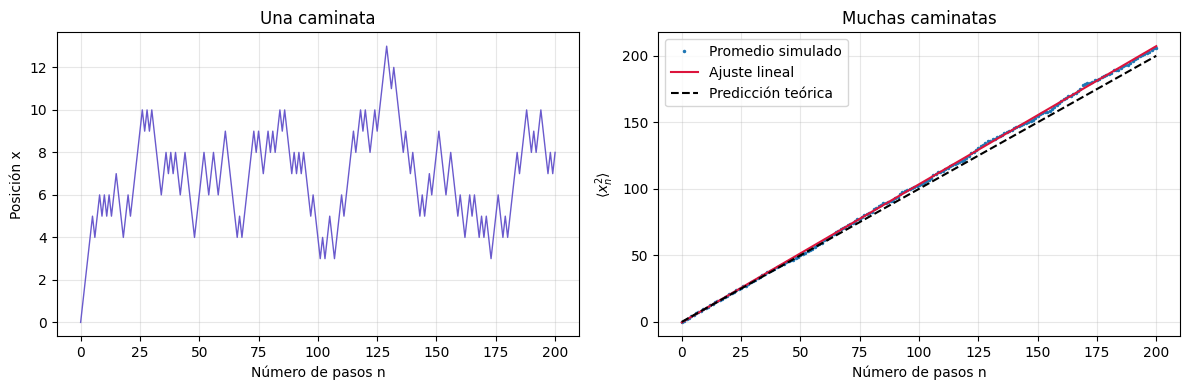

Pendiente=1.03839; intercepto=-0.40870
D estimado=0.51919; D teórico=0.50000 (longitud²/tiempo)


In [ ]:
# --- Parámetros del experimento ---
K, N = 2000, 200            # caminantes y pasos por caminante
a, delta_t = 1.0, 1.0       # longitud de paso e intervalo de tiempo
semilla = 2026              # semilla del resultado entregado

# --- Simulación y ajuste lineal de <x_n^2> frente a n ---
media_x, media_x2 = simular_caminatas(K, N, a, semilla)
pasos = list(range(N + 1))
pendiente, intercepto = ajuste_lineal(pasos, media_x2)

# --- Coeficiente de difusión: estimado (del ajuste) y teórico ---
D_estimado = pendiente / (2*delta_t)  # pendiente / (2*delta_t)
D_teorico = a*a / (2*delta_t)   # a*a / (2*delta_t)
ajuste = [pendiente*n + intercepto for n in pasos]   # recta ajustada, para graficar

# --- Una trayectoria individual, para comparar con el promedio ---
# La semilla distinta permite mostrar una trayectoria reproducible e independiente.
trayectoria = caminar(N, a, random.Random(2027))

# --- Guardar los resultados en un archivo CSV ---
with open("caminata_difusion.csv", "w", encoding="utf-8") as archivo:
    archivo.write("n,media_x,media_x2,ajuste\n")
    for n in pasos:
        archivo.write(f"{n},{media_x[n]},{media_x2[n]},{ajuste[n]}\n")

# --- Figura: trayectoria individual (izquierda) y promedios (derecha) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(pasos, trayectoria, color="slateblue", linewidth=1)
ax1.set(xlabel="Número de pasos n", ylabel="Posición x", title="Una caminata")
ax2.plot(pasos, media_x2, ".", markersize=3, label="Promedio simulado")
ax2.plot(pasos, ajuste, color="crimson", label="Ajuste lineal")
ax2.plot(pasos, [n*a*a for n in pasos], "--", color="black", label="Predicción teórica")
ax2.set(xlabel="Número de pasos n", ylabel=r"$\langle x_n^2\rangle$", title="Muchas caminatas")
for ax in (ax1, ax2):
    ax.grid(alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.savefig("caminata_difusion.png", dpi=180, bbox_inches="tight")
plt.show()

# --- Resumen numérico ---
print(f"Pendiente={pendiente:.5f}; intercepto={intercepto:.5f}")
print(f"D estimado={D_estimado:.5f}; D teórico={D_teorico:.5f} (longitud²/tiempo)")


### Exploración requerida

Repita la simulación con, por ejemplo, $K=100$ y $K=2000$, conservando $N$, $a$, $\Delta t$ y la semilla. Calcule el coeficiente de difusión $D$ en cada caso. Explique por qué la cercanía a $D_{\rm teórico}$ **no tiene que mejorar de manera monótona** en solo dos ejecuciones, aunque la precisión típica sí mejora al promediar más caminatas. Si cambia la semilla, documente el cambio.

**Extensión opcional (Computational Physics, Giordano, ejercicio 7.3):** modifique las probabilidades de derecha e izquierda. Compare $\langle x_n^2\rangle$ con $\operatorname{Var}(x_n)=\langle x_n^2\rangle-\langle x_n\rangle^2$. Discuta cuál separa la dispersión de la deriva promedio. No use $m/(2\Delta t)$ de $\langle x^2\rangle$ como coeficiente de difusión en presencia de deriva.

In [ ]:
# Exploración requerida — comparar dos tamaños del conjunto
resultados_K = {}
for K_prueba in (100, 2000):
    _, x2_prueba = simular_caminatas(K_prueba, N, a, semilla)
    m_prueba, b_prueba = ajuste_lineal(pasos, x2_prueba)
    D_prueba = m_prueba/(2*delta_t)
    resultados_K[K_prueba] = (m_prueba, b_prueba, D_prueba)
    print(f"K={K_prueba:4d}: pendiente={m_prueba:.5f}, b={b_prueba:.5f}, D={D_prueba:.5f}")

D_K100 = resultados_K[100][2]
D_K2000 = resultados_K[2000][2]


K= 100: pendiente=1.33523, b=-11.74962, D=0.66761
K=2000: pendiente=1.03839, b=-0.40870, D=0.51919


**Interpretación.** Aumentar $K$ reduce la fluctuación estadística típica del promedio, pero en dos realizaciones concretas la cercanía a $D_{\rm teórico}=0.5$ no tiene que mejorar de forma monótona. Una muestra pequeña puede quedar accidentalmente muy cerca del valor teórico, mientras otra muestra más grande puede desviarse ligeramente en la dirección contraria.

## Parte D — Efecto de un mal generador sobre el coeficiente de difusión

En las diapositivas se mostró que el generador congruencial $(a,c,M,r_1)=(57,1,256,10)$ produce pares consecutivos alineados en una rejilla. Ahora se medirá el efecto de ese defecto sobre **un resultado físico**: el coeficiente de difusión $D$.

La clase `GeneradorLCG` de la celda siguiente ya está completa. Tiene un método `random()` que devuelve $r_i/M$, igual que `random.Random`; por eso puede entregarse directamente a `simular_caminatas` mediante el argumento `generador`. Ejecútela sin modificarla.

### Actividades

1. Ejecute la simulación con $K=2000$, $N=200$, $a=1$, $\Delta t=1$ usando tres generadores: `random.Random(2026)`, el LCG deficiente `GeneradorLCG(57, 1, 256, 10)` y el LCG de parámetros de `drand48`, `GeneradorLCG(0x5DEECE66D, 11, 2**48, 10)`.
2. Ajuste una recta a $\langle x_n^2\rangle$ en cada caso con `ajuste_lineal` y calcule el coeficiente de difusión $D$. Guarde los resultados en `D_lcg_malo` y `D_drand48`.
3. Represente $\langle x_n^2\rangle$ frente a $n$ para los tres generadores en una misma figura.
4. Guarde en `trayectoria_lcg_larga` **una sola** caminata de 1024 pasos con el LCG deficiente e imprima la posición en $n = 0, 256, 512, 768, 1024$. Explique el resultado usando el período del generador.
5. Responda: ¿qué coeficiente de difusión habría reportado un investigador que usara este generador sin probarlo? ¿Por qué las pruebas de media y de pares consecutivos del Ejercicio 1 son necesarias antes de simular?


In [ ]:
class GeneradorLCG:
    """Generador lineal congruente r_{i+1} = (a r_i + c) mod M.

    El método random() devuelve r/M en [0, 1), con la misma interfaz que
    random.Random, de modo que puede reemplazarlo en simular_caminatas.
    """

    # --- Constructor: guarda los parámetros y el estado inicial (la semilla) ---
    def __init__(self, a, c, M, semilla):
        self.a, self.c, self.M = a, c, M
        self.r = semilla % M          # el estado siempre está en 0, ..., M-1

    # --- Un número nuevo: actualiza el estado y lo escala a [0, 1) ---
    def random(self):
        self.r = (self.a*self.r + self.c) % self.M   # recurrencia congruencial
        return self.r / self.M                       # división real


# --- Comprobación con la secuencia de las diapositivas (a=4, c=1, M=9, r1=3) ---
demo = GeneradorLCG(4, 1, 9, 3)
print([round(demo.random()*9) for _ in range(9)])  # debe dar 4, 8, 6, 7, 2, 0, 1, 5, 3


[4, 8, 6, 7, 2, 0, 1, 5, 3]


D con random.Random : 0.5192
D con LCG deficiente: 0.0862
D con LCG drand48   : 0.4855   (teórico 0.5)


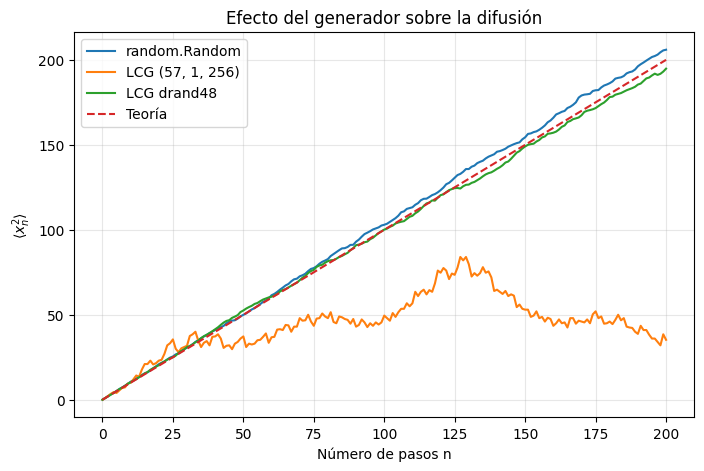

Posiciones en n = 0, 256, 512, 768, 1024:
[0.0, 0.0, 0.0, 0.0, 0.0]


In [ ]:
# Parte D — Comparación de generadores

# --- Parámetros comunes a los tres experimentos ---
K_gen, N_gen = 2000, 200
pasos_gen = list(range(N_gen + 1))

# --- Misma simulación con tres generadores distintos ---
_, x2_bueno = simular_caminatas(K_gen, N_gen, 1.0, 2026)
_, x2_malo = simular_caminatas(
    K_gen, N_gen, 1.0, None,
    generador=GeneradorLCG(57, 1, 256, 10)
)
_, x2_drand48 = simular_caminatas(
    K_gen, N_gen, 1.0, None,
    generador=GeneradorLCG(0x5DEECE66D, 11, 2**48, 10)
)

# --- Pendiente y coeficiente de difusión ---
m_bueno, _ = ajuste_lineal(pasos_gen, x2_bueno)
m_malo, _ = ajuste_lineal(pasos_gen, x2_malo)
m_drand48, _ = ajuste_lineal(pasos_gen, x2_drand48)

D_bueno = m_bueno/2
D_lcg_malo = m_malo/2
D_drand48 = m_drand48/2
print(f"D con random.Random : {D_bueno:.4f}")
print(f"D con LCG deficiente: {D_lcg_malo:.4f}")
print(f"D con LCG drand48   : {D_drand48:.4f}   (teórico 0.5)")

# --- Gráfica comparativa ---
plt.figure(figsize=(8, 5))
plt.plot(pasos_gen, x2_bueno, label="random.Random")
plt.plot(pasos_gen, x2_malo, label="LCG (57, 1, 256)")
plt.plot(pasos_gen, x2_drand48, label="LCG drand48")
plt.plot(pasos_gen, pasos_gen, "--", label="Teoría")
plt.xlabel("Número de pasos n")
plt.ylabel(r"$\langle x_n^2\rangle$")
plt.title("Efecto del generador sobre la difusión")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- Una caminata larga con el LCG deficiente ---
trayectoria_lcg_larga = caminar(1024, 1.0, GeneradorLCG(57, 1, 256, 10))
print("Posiciones en n = 0, 256, 512, 768, 1024:")
print([trayectoria_lcg_larga[n] for n in (0, 256, 512, 768, 1024)])


**Interpretación de la Parte D.** El LCG $(57,1,256,10)$ produce un valor de $D$ muy inferior al teórico. Aunque sus valores pueden parecer repartidos en $[0,1)$, existen correlaciones entre números consecutivos. Su período es 256 y la caminata regresa al origen cada 256 pasos, por lo que la dispersión queda artificialmente limitada. Un investigador que no probara el generador reportaría un coeficiente de difusión físicamente incorrecto. Por eso se revisan tanto la media como los pares consecutivos antes de usar una secuencia en una simulación.

## Parte E — Difusión en unidades reales

Hasta ahora $a=1$ y $\Delta t=1$ en unidades arbitrarias. Para dar sentido físico al resultado, considere una molécula de oxígeno disuelta en agua a temperatura ambiente, cuyo coeficiente de difusión $D$ es aproximadamente

$$D_{\rm O_2}\approx 2\times10^{-9}\ \text{m}^2/\text{s}.$$

El modelo de caminata reproduce ese valor si la longitud del paso y el intervalo cumplen $D=a^2/(2\Delta t)$. El tiempo característico para que el desplazamiento cuadrático medio alcance $L^2$ es, en una dimensión,

$$t(L)\approx\frac{L^2}{2D}.$$

### Actividades

1. Con $\Delta t = 1\ \mu\text{s}$, calcule la longitud de paso `a_fisico` (en metros) que reproduce $D_{\rm O_2}$.
2. Convierta la pendiente `pendiente` obtenida en la Parte C (en unidades de $a^2$ por paso) a un coeficiente de difusión en m²/s: $D_{\rm sim} = m\,a_{\rm fisico}^2/(2\Delta t)$. Compárelo con $D_{\rm O_2}$.
3. Calcule `t_celula`, `t_mm` y `t_cm`: el tiempo para difundir $L = 10\ \mu\text{m}$ (el tamaño de una célula), $1$ mm y $1$ cm. Exprese cada uno en la unidad más legible (s, min, h).
4. Calcule también el tiempo para $L = 1$ m en agua quieta y expréselo en años.
5. ¿Cuántos pasos $N$ necesitaría la simulación para representar la difusión a lo largo de 1 cm con el paso `a_fisico`? Comente por qué, a escalas grandes, se usa la ecuación de difusión en lugar de simular cada paso.
6. Discuta brevemente: la difusión basta para transportar oxígeno dentro de una célula, pero ¿basta para mezclar un contaminante en un lago? ¿Qué otro mecanismo de transporte domina a escalas grandes?


**Interpretación:** este tiempo corresponde a una distancia raíz cuadrática media $x_{\mathrm{rms}}=L$. No es el tiempo en que todas las partículas alcanzan $L$, ni garantiza mezcla completa. El paso `a_fisico` es una longitud efectiva de este modelo: no se identifica necesariamente con la distancia entre colisiones moleculares. El valor de $D_{\rm O_2}$ se usa como dato aproximado del ejercicio; depende de las condiciones del medio.


In [ ]:
# Parte E — Difusión en unidades reales

# --- Datos físicos ---
D_O2 = 2e-9          # m^2/s
dt_fisico = 1e-6     # s

# --- Longitud de paso y coeficiente de difusión simulado ---
a_fisico = (2*D_O2*dt_fisico)**0.5
D_sim = pendiente*a_fisico**2/(2*dt_fisico)

# --- Tiempo característico de difusión ---
def tiempo_difusion(L, D):
    """Tiempo t = L^2/(2D) para alcanzar una distancia RMS L en una dimensión."""
    if D <= 0:
        raise ValueError("D debe ser positivo")
    return L**2/(2*D)

# --- Tiempos para distintas escalas de longitud ---
t_celula = tiempo_difusion(10e-6, D_O2)
t_mm = tiempo_difusion(1e-3, D_O2)
t_cm = tiempo_difusion(1e-2, D_O2)
t_m = tiempo_difusion(1.0, D_O2)

# --- Número de pasos para representar 1 cm ---
N_cm = (1e-2/a_fisico)**2

# --- Resultados en unidades legibles ---
print(f"a = {a_fisico*1e9:.1f} nm;  D_sim = {D_sim:.3e} m^2/s  (referencia {D_O2:.1e})")
print(f"10 µm: {t_celula:.3g} s")
print(f"1 mm : {t_mm:.3g} s = {t_mm/60:.3g} min")
print(f"1 cm : {t_cm:.3g} s = {t_cm/3600:.3g} h")
print(f"1 m  : {t_m/(3600*24*365.25):.3g} años")
print(f"Pasos para 1 cm: {N_cm:.2e}")


a = 63.2 nm;  D_sim = 2.077e-09 m^2/s  (referencia 2.0e-09)
10 µm: 0.025 s
1 mm : 250 s = 4.17 min
1 cm : 2.5e+04 s = 6.94 h
1 m  : 7.92 años
Pasos para 1 cm: 2.50e+10


**Interpretación de la Parte E.** La difusión es eficaz en distancias microscópicas: para $10\,\mu$m el tiempo característico es de centésimas de segundo. Al aumentar la escala, el tiempo crece como $L^2$, por lo que llegar a 1 cm requiere horas y a 1 m requiere años. Simular 1 cm paso a paso exige del orden de $10^{10}$ pasos, de modo que a escalas grandes es más práctico resolver una ecuación de difusión. En un lago, además, la mezcla macroscópica está dominada principalmente por transporte advectivo y movimientos del fluido, no por difusión molecular pura.

## Verificación final PASS/FAIL

Ejecute esta celda después de completar el taller. Las pruebas usan entradas controladas para verificar las funciones y revisan los archivos generados. La comparación estadística del valor de $D$ permite fluctuaciones razonables; no exige igualdad exacta. **Un PASS no reemplaza la revisión del código, las unidades, la figura y la interpretación física.**

In [ ]:
# --- Bibliotecas para leer el CSV y comparar números reales ---
import csv
import math
from pathlib import Path

# --- Registro de resultados: imprime PASS/FAIL y guarda cada veredicto ---
veredictos = []
def informar(nombre, condicion, detalle=""):
    estado = "PASS" if condicion else "FAIL"
    veredictos.append(condicion)
    print(f"{estado} | {nombre}" + (f" — {detalle}" if detalle else ""))

# --- Generador de prueba: devuelve valores fijados de antemano ---
class RngControlado:
    def __init__(self, valores):
        self.valores = iter(valores)
    def random(self):
        return next(self.valores)

# --- Prueba 1: regla del paso (umbral en 0.5) ---
try:
    pasos_prueba = [generar_paso(RngControlado([u]), 2.0) for u in (0.0, 0.49, 0.5, 0.99)]
    informar("Regla del paso y umbral 0.5", pasos_prueba == [2.0, 2.0, -2.0, -2.0])
except Exception as exc:
    informar("Regla del paso y umbral 0.5", False, str(exc))

# --- Prueba 2: trayectoria con números controlados ---
try:
    posiciones_prueba = list(caminar(4, 2.0, RngControlado([0.1, 0.7, 0.2, 0.8])))
    informar("Trayectoria y posición inicial", posiciones_prueba == [0.0, 2.0, 0.0, 2.0, 0.0])
except Exception as exc:
    informar("Trayectoria y posición inicial", False, str(exc))

# --- Prueba 3: ajuste lineal con datos exactos ---
try:
    m_prueba, b_prueba = ajuste_lineal([0, 1, 2, 3], [2, 5, 8, 11])
    informar("Ajuste lineal con datos conocidos", math.isclose(m_prueba, 3.0, abs_tol=1e-10) and math.isclose(b_prueba, 2.0, abs_tol=1e-10))
except Exception as exc:
    informar("Ajuste lineal con datos conocidos", False, str(exc))

# --- Pruebas 4-7: estructura, reproducibilidad, simetría y crecimiento difusivo ---
try:
    mx1, mx21 = simular_caminatas(2000, 100, 1.0, 12345)
    mx2, mx22 = simular_caminatas(2000, 100, 1.0, 12345)
    estructura = (len(mx1) == len(mx21) == 101 and
                  math.isclose(mx1[0], 0.0) and math.isclose(mx21[0], 0.0) and
                  all(math.isfinite(float(v)) for v in list(mx1) + list(mx21)))
    informar("Longitud, origen y valores finitos", estructura)
    informar("Reproducibilidad con la misma semilla", list(mx1) == list(mx2) and list(mx21) == list(mx22))
    if estructura:
        exactitud_media = all(abs(mx1[n]) <= 0.20*math.sqrt(n) + 0.1 for n in (25, 50, 100))
        informar("Media de posición compatible con simetría", exactitud_media)
        m_test, _ = ajuste_lineal(list(range(101)), mx21)
        informar("Crecimiento difusivo promedio", math.isfinite(m_test) and abs(m_test - 1.0) < 0.15, f"pendiente={m_test:.4f}")
    else:
        informar("Media de posición compatible con simetría", False)
        informar("Crecimiento difusivo promedio", False)
except Exception as exc:
    for nombre in ("Longitud, origen y valores finitos", "Reproducibilidad con la misma semilla", "Media de posición compatible con simetría", "Crecimiento difusivo promedio"):
        informar(nombre, False, str(exc))

# --- Prueba 8: parámetros inválidos deben producir ValueError ---
try:
    rechazos = []
    for llamada in (lambda: caminar(-1, 1.0, random.Random(1)),
                    lambda: simular_caminatas(0, 10, 1.0, 1),
                    lambda: ajuste_lineal([1, 1], [2, 3])):
        try:
            llamada()
            rechazos.append(False)
        except ValueError:
            rechazos.append(True)
    informar("Parámetros y ajuste degenerado rechazados", all(rechazos))
except Exception as exc:
    informar("Parámetros y ajuste degenerado rechazados", False, str(exc))

# --- Prueba 9: archivo CSV completo y consistente ---
try:
    datos = list(csv.DictReader(open("caminata_difusion.csv", encoding="utf-8")))
    columnas = set(datos[0]) if datos else set()
    valido = (len(datos) == N + 1 and columnas == {"n", "media_x", "media_x2", "ajuste"}
              and [int(fila["n"]) for fila in datos] == list(range(N+1)))
    if valido:
        valido = all(math.isclose(float(fila["media_x2"]), float(media_x2[i]), abs_tol=1e-10)
                     and math.isclose(float(fila["ajuste"]), pendiente*i + intercepto, abs_tol=1e-9)
                     for i, fila in enumerate(datos))
    informar("CSV completo y consistente con el ajuste", valido)
except Exception as exc:
    informar("CSV completo y consistente con el ajuste", False, str(exc))

# --- Prueba 10: conversión de la pendiente al coeficiente de difusión ---
try:
    correcto_D = (math.isclose(D_estimado, pendiente/(2*delta_t), rel_tol=1e-10, abs_tol=1e-10)
                   and math.isclose(D_teorico, a*a/(2*delta_t), rel_tol=1e-10, abs_tol=1e-10))
    informar("Conversión de la pendiente al coeficiente de difusión", correcto_D)
except Exception as exc:
    informar("Conversión de la pendiente al coeficiente de difusión", False, str(exc))

# --- Prueba 11: simular_caminatas acepta un generador externo (Parte D) ---
try:
    _, x2_ctrl = simular_caminatas(1, 2, 1.0, None, generador=RngControlado([0.1, 0.7]))
    informar("simular_caminatas acepta un generador externo", [float(t) for t in x2_ctrl] == [0.0, 1.0, 0.0])
except Exception as exc:
    informar("simular_caminatas acepta un generador externo", False, str(exc))

# --- Pruebas 12-13: coeficiente de difusión con el LCG deficiente y con drand48 ---
try:
    informar("LCG deficiente: resultado del experimento especificado", math.isfinite(D_lcg_malo) and math.isclose(D_lcg_malo, 0.08623725432244717, rel_tol=1e-6, abs_tol=1e-8), f"D_lcg_malo={D_lcg_malo:.4f}")
    informar("LCG drand48: coeficiente de difusión compatible con 0.5", abs(D_drand48 - 0.5) < 0.075, f"D_drand48={D_drand48:.4f}")
except Exception as exc:
    informar("LCG deficiente: resultado del experimento especificado", False, str(exc))
    informar("LCG drand48: coeficiente de difusión compatible con 0.5", False, str(exc))

# --- Pruebas 14-15: unidades reales (Parte E) ---
try:
    ok_a = math.isclose(a_fisico, math.sqrt(2*D_O2*dt_fisico), rel_tol=1e-9)
    ok_Dsim = math.isclose(D_sim, pendiente*a_fisico**2/(2*dt_fisico), rel_tol=1e-9)
    informar("Paso físico y coeficiente de difusión en m²/s", ok_a and ok_Dsim, f"a={a_fisico*1e9:.1f} nm, D_sim={D_sim:.2e} m²/s")
    ok_t = (math.isclose(t_celula, 0.025, rel_tol=1e-9) and math.isclose(t_cm, 2.5e4, rel_tol=1e-9)
            and math.isclose(t_mm, 250.0, rel_tol=1e-9) and math.isclose(t_m, 2.5e8, rel_tol=1e-9)
            and math.isclose(N_cm, (1e-2/a_fisico)**2, rel_tol=1e-6))
    informar("Tiempos de difusión y número de pasos", ok_t, f"t(10 µm)={t_celula:.3g} s, t(1 cm)={t_cm/3600:.2f} h")
except Exception as exc:
    informar("Paso físico y coeficiente de difusión en m²/s", False, str(exc))
    informar("Tiempos de difusión y número de pasos", False, str(exc))

# Prueba determinista de la caminata larga: no llama a las funciones del estudiante.
try:
    estado_ref = 10
    x_ref = 0.0
    recorrido_ref = [x_ref]
    for _ in range(1024):
        estado_ref = (57*estado_ref + 1) % 256
        x_ref += 1.0 if estado_ref/256 < 0.5 else -1.0
        recorrido_ref.append(x_ref)
    informar("Caminata larga con LCG: trayectoria y retornos periódicos",
             list(trayectoria_lcg_larga) == recorrido_ref)
except Exception as exc:
    informar("Caminata larga con LCG: trayectoria y retornos periódicos", False, str(exc))

# --- Prueba 16: la figura fue guardada ---
figura = Path("caminata_difusion.png")
informar("Figura generada", figura.is_file() and figura.stat().st_size > 1000)
# --- Resumen final ---
print(f"Resumen: {sum(veredictos)}/{len(veredictos)} PASS")

PASS | Regla del paso y umbral 0.5
PASS | Trayectoria y posición inicial
PASS | Ajuste lineal con datos conocidos
PASS | Longitud, origen y valores finitos
PASS | Reproducibilidad con la misma semilla
PASS | Media de posición compatible con simetría
PASS | Crecimiento difusivo promedio — pendiente=1.0147
PASS | Parámetros y ajuste degenerado rechazados
PASS | CSV completo y consistente con el ajuste
PASS | Conversión de la pendiente al coeficiente de difusión
PASS | simular_caminatas acepta un generador externo
PASS | LCG deficiente: resultado del experimento especificado — D_lcg_malo=0.0862
PASS | LCG drand48: coeficiente de difusión compatible con 0.5 — D_drand48=0.4855
PASS | Paso físico y coeficiente de difusión en m²/s — a=63.2 nm, D_sim=2.08e-09 m²/s
PASS | Tiempos de difusión y número de pasos — t(10 µm)=0.025 s, t(1 cm)=6.94 h
PASS | Caminata larga con LCG: trayectoria y retornos periódicos
PASS | Figura generada
Resumen: 17/17 PASS
